# "Ungewöhnliche" Spektren erkennen — Drei einfache Methoden zur Anomalie-Erkennung

Eine sehr praktische Frage taucht immer wieder auf: *Woran erkennen wir, dass
ein Spektrum ungewöhnlich aussieht?* Dieses Notebook geht drei einfache, sich
ergänzende Wege durch, das zu beantworten — vom einfachen
Qualitätskontroll-Instinkt, den man vermutlich schon kennt, bis zur
Wasserstein-Distanz-Idee, die konzeptionell in
`notebooks/Wasserstein_Metrik.ipynb` eingeführt wird.

Es werden keine gelabelten Fehlerdaten verwendet — "ungewöhnlich" wird rein
aus den Daten selbst definiert (siehe `results.md`, warum `Alarmlevel` keine
echte Ground Truth ist). Ziel ist nicht, einen fertigen Detektor zu bauen,
sondern ein Gefühl für die Kompromisse zwischen den Methoden zu entwickeln —
anhand einer echten Sensor+Workstep-Gruppe aus den tatsächlichen
Schleifdaten.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance

plt.rcParams["figure.dpi"] = 110

## 1. Eine Sensor+Workstep-Gruppe laden

Wir verwenden **Sensor 2 bei Workstep 111** (Schruppen Spindel 1) — einen
normalen Produktionsschritt, abseits der sensor-1-spezifischen
`Alarmlevel`-Eigenheit und dem Warmlaufschritt Workstep 3 (siehe
`results.md`).

In [2]:
data = pd.read_parquet("../data/processed/combined_measurements.parquet")
group = data[(data["sensor"] == 2) & (data["workstep"] == 111)].reset_index(drop=True)
print(f"{len(group):,} Messungen")

wert_cols = sorted(
    [c for c in group.columns if c.startswith("Wert")],
    key=lambda c: int(c.replace("Wert", "")),
)[1:]  # Wert1 verwerfen, der 0 Hz / DC-Bin -- konstant 0, verzerrt nur den dB-Plot

frequency_resolution_hz = 6.103515625
freqs = np.array([int(c.replace("Wert", "")) for c in wert_cols]) * frequency_resolution_hz

max_freq = 500  # die interessanten Harmonischen liegen deutlich darunter (siehe results.md)
keep = freqs <= max_freq
wert_cols = list(np.array(wert_cols)[keep])
freqs = freqs[keep]

X = group[wert_cols].to_numpy()             # lineare Amplitude, mG
X_db = 20 * np.log10(np.maximum(X, 1e-12))  # dB, für Plot / Formvergleich
print(f"{len(freqs)} Frequenz-Bins, bis {freqs.max():.0f} Hz")

9,208 Messungen
80 Frequenz-Bins, bis 494 Hz


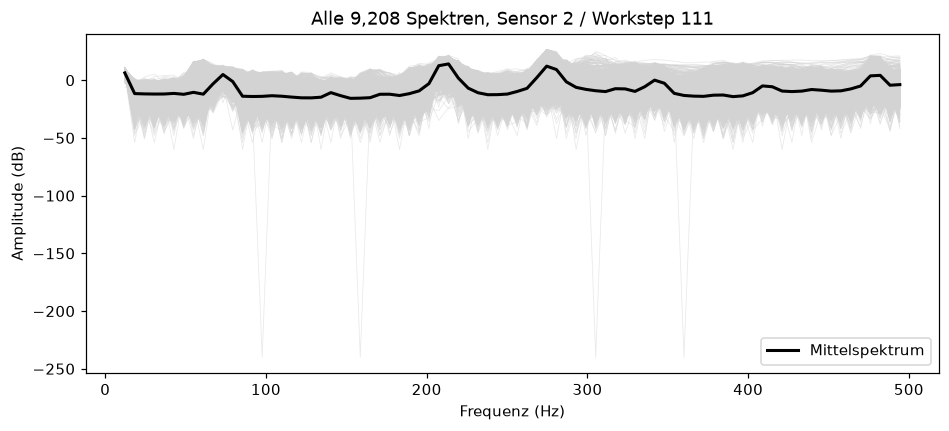

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, X_db.T, color="lightgray", linewidth=0.5, alpha=0.5)
ax.plot(freqs, X_db.mean(axis=0), color="black", linewidth=2, label="Mittelspektrum")
ax.set_xlabel("Frequenz (Hz)")
ax.set_ylabel("Amplitude (dB)")
ax.set_title(f"Alle {len(X_db):,} Spektren, Sensor 2 / Workstep 111")
ax.legend()
plt.show()

Erkennst du die ungewöhnlichen von Auge? Ein paar vielleicht — aber die
meisten dieser ~9.000 Messungen sehen gleich aus, und irgendwo dazwischen
stecken Ausreißer. Drei Wege, sie zu finden, in aufsteigender Reihenfolge,
wie viel von der *Form* sie tatsächlich betrachten.

## Methode 1: Eine einzelne Zahl + ein Schwellenwert (der Qualitätskontroll-Instinkt)

Jedes Spektrum auf **eine Zahl** reduzieren — hier die Gesamtenergie (Summe
der quadrierten Amplitude über alle Bins) — und alles markieren, was mehr
als 3 Standardabweichungen über dem Gruppen-Mittelwert liegt. Das ist genau
die Logik hinter einer klassischen Statistical-Process-Control-Karte.

179 / 9208 Messungen markiert (Mittelwert + 3 std)


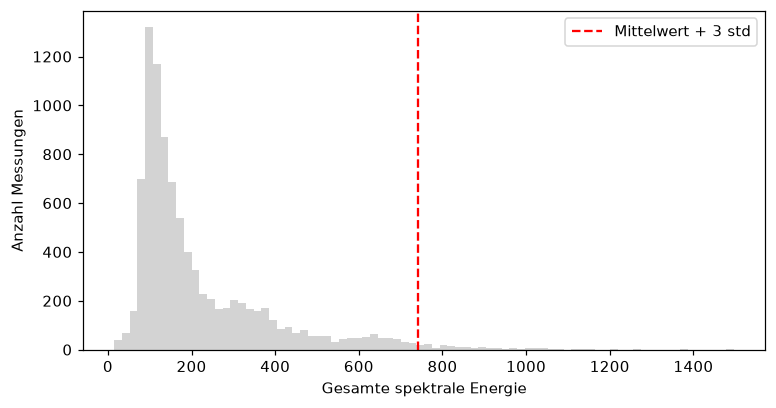

In [4]:
energy = (X ** 2).sum(axis=1)

mean_e, std_e = energy.mean(), energy.std()
threshold_e = mean_e + 3 * std_e
flagged_energy = energy > threshold_e

print(f"{flagged_energy.sum()} / {len(energy)} Messungen markiert (Mittelwert + 3 std)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(energy, bins=80, color="lightgray")
ax.axvline(threshold_e, color="red", linestyle="--", label="Mittelwert + 3 std")
ax.set_xlabel("Gesamte spektrale Energie")
ax.set_ylabel("Anzahl Messungen")
ax.legend()
plt.show()

**Der Haken:** Diese Methode betrachtet nur eine einzige Zahl — die
Gesamtenergie. Zwei Spektren mit exakt derselben Gesamtenergie, aber völlig
unterschiedlicher *Form* (ein großer Peak vs. fünf kleine, verteilte) sehen
für sie identisch aus. Schnell und vertraut, aber blind für die Form.

## Methode 2: Euklidische Distanz zum Mittelspektrum

Jedes Spektrum als Punkt im Raum auffassen — eine Dimension pro
Frequenz-Bin — und die einfache geradlinige ("euklidische") Distanz zum
Durchschnittsspektrum der Gruppe messen. Das betrachtet *tatsächlich* die
gesamte Form, nicht nur eine Zahl.

In [5]:
mean_db = X_db.mean(axis=0)
euclidean_dist = np.linalg.norm(X_db - mean_db, axis=1)

flag_pct = 99  # die abweichendsten 1% der Messungen markieren
threshold_euclid = np.percentile(euclidean_dist, flag_pct)
flagged_euclid = euclidean_dist >= threshold_euclid

print(f"{flagged_euclid.sum()} / {len(euclidean_dist)} Messungen markiert (Top {100 - flag_pct:.0f}%)")

93 / 9208 Messungen markiert (Top 1%)


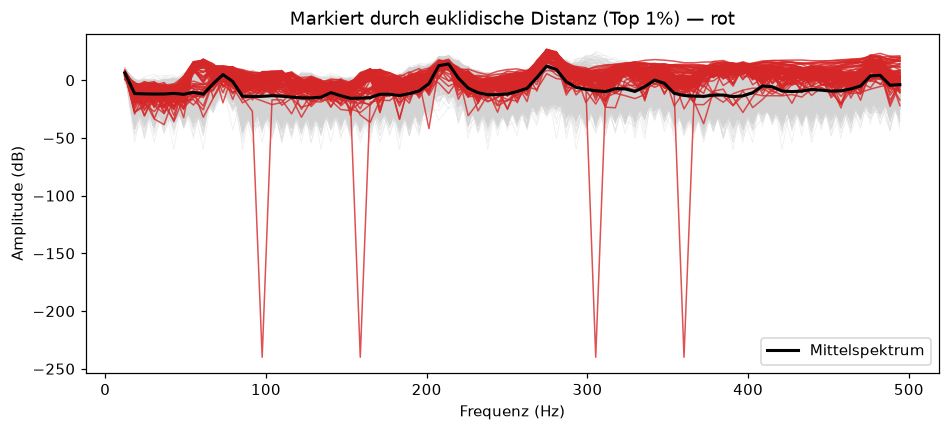

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, X_db[~flagged_euclid].T, color="lightgray", linewidth=0.5, alpha=0.4)
ax.plot(freqs, X_db[flagged_euclid].T, color="tab:red", linewidth=1, alpha=0.8)
ax.plot(freqs, mean_db, color="black", linewidth=2, label="Mittelspektrum")
ax.set_xlabel("Frequenz (Hz)")
ax.set_ylabel("Amplitude (dB)")
ax.set_title(f"Markiert durch euklidische Distanz (Top {100 - flag_pct:.0f}%) — rot")
ax.legend()
plt.show()

**Der Haken:** Die euklidische Distanz vergleicht Bin für Bin. Wenn ein Peak
nur um ein, zwei Bins *verschoben* ist (etwa eine leicht andere Drehzahl),
sonst aber gleich aussieht, kann die euklidische Distanz das als sehr
unterschiedlich bewerten — sie hat kein Gespür dafür, dass "ein Peak in der
Nähe" ähnlicher ist als "ein Peak weit weg". Genau diese Lücke schließt die
Wasserstein-Distanz.

## Methode 3: Wasserstein-Distanz zum Referenzspektrum

Die Wasserstein- ("Erdbewegungs-") Distanz behandelt jedes Spektrum als
einen Haufen Masse, verteilt über die Frequenz, und fragt, wie viel *Arbeit*
(Masse × zurückgelegte Distanz) es kostet, einen Haufen in den anderen
umzuformen. Ein um einen Bin verschobener Peak kostet wenig; ein Peak, der
irgendwo völlig anders auftaucht, kostet viel — das kommt der Beurteilung
"von Auge" deutlich näher als die euklidische Distanz.

Wir vergleichen jede Messung mit dem arithmetischen Durchschnittsspektrum
der Gruppe. Das ist nicht ganz dasselbe wie der echte
**Wasserstein-Barycenter** — `notebooks/Wasserstein_Metrik.ipynb` zeigt ein
Spielzeugbeispiel (zwei getrennte Gauß-Verteilungen), bei dem diese beiden
Referenzen tatsächlich unterschiedliche Formen sind. Für reale Spektren wie
diese, bei denen die Variation zwischen Messungen eine milde Umformung ist
und keine dramatische Aufspaltung, ist der einfache Durchschnitt ein sehr
naher, deutlich billigerer Ersatz für den Barycenter.

In [7]:
# wasserstein_distance braucht nicht-negative Gewichte -- beide um dieselbe
# Konstante nach oben verschieben (ändert nie die *Distanz*, da sie
# verschiebungsinvariant in der Masse ist)
shift = min(X_db.min(), mean_db.min()) - 1e-6

wasserstein_dist = np.array([
    wasserstein_distance(freqs, freqs, row - shift, mean_db - shift)
    for row in X_db
])

threshold_wasserstein = np.percentile(wasserstein_dist, flag_pct)
flagged_wasserstein = wasserstein_dist >= threshold_wasserstein

print(f"{flagged_wasserstein.sum()} / {len(wasserstein_dist)} Messungen markiert (Top {100 - flag_pct:.0f}%)")

93 / 9208 Messungen markiert (Top 1%)


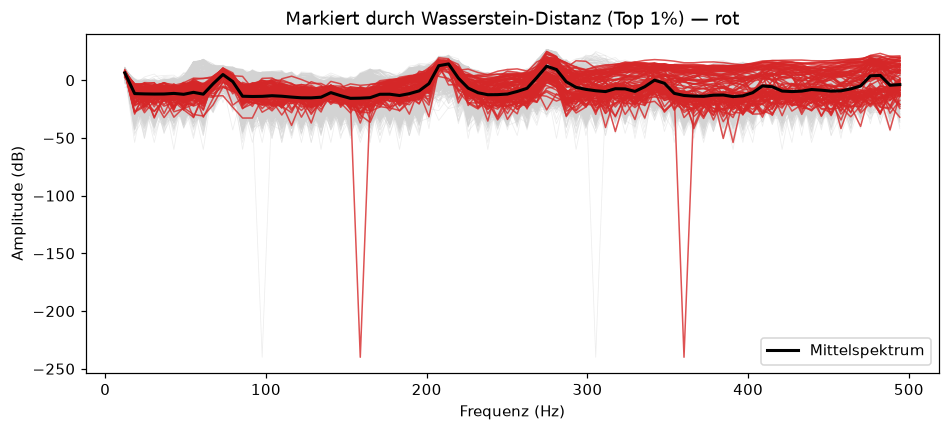

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, X_db[~flagged_wasserstein].T, color="lightgray", linewidth=0.5, alpha=0.4)
ax.plot(freqs, X_db[flagged_wasserstein].T, color="tab:red", linewidth=1, alpha=0.8)
ax.plot(freqs, mean_db, color="black", linewidth=2, label="Mittelspektrum")
ax.set_xlabel("Frequenz (Hz)")
ax.set_ylabel("Amplitude (dB)")
ax.set_title(f"Markiert durch Wasserstein-Distanz (Top {100 - flag_pct:.0f}%) — rot")
ax.legend()
plt.show()

## Die drei im Vergleich

Dieselben ~9.000 Messungen, drei verschiedene Definitionen von
"ungewöhnlich" — wie sehr stimmen sie tatsächlich überein?

In [9]:
flags = pd.DataFrame({
    "Energie (Mittel+3std)": flagged_energy,
    "euklidisch (Top 1%)": flagged_euclid,
    "Wasserstein (Top 1%)": flagged_wasserstein,
})

print("Von jeder Methode markierte Messungen:")
print(flags.sum().to_string())

print("\nPaarweise Überschneidung (von beiden Methoden markiert):")
methods = list(flags.columns)
for i in range(len(methods)):
    for j in range(i + 1, len(methods)):
        overlap = (flags[methods[i]] & flags[methods[j]]).sum()
        print(f"  {methods[i]!r} & {methods[j]!r}: {overlap}")

Von jeder Methode markierte Messungen:
Energie (Mittel+3std)    179
euklidisch (Top 1%)       93
Wasserstein (Top 1%)      93

Paarweise Überschneidung (von beiden Methoden markiert):
  'Energie (Mittel+3std)' & 'euklidisch (Top 1%)': 67
  'Energie (Mittel+3std)' & 'Wasserstein (Top 1%)': 11
  'euklidisch (Top 1%)' & 'Wasserstein (Top 1%)': 21


## Erkenntnisse

- **Gesamtenergie + Schwellenwert** ist am schnellsten und vertrautesten
  (klassisches SPC), aber blind für die *Form* — ein umsortiertes Spektrum
  mit derselben Gesamtenergie kommt ungehindert durch.
- **Euklidische Distanz** betrachtet die gesamte Form, bestraft aber kleine
  Frequenzverschiebungen hart — empfindlich dafür, *genau wo* ein Peak sitzt.
- **Wasserstein-Distanz** betrachtet ebenfalls die gesamte Form, toleriert
  aber kleine Verschiebungen großzügig — meist die Methode, die am ehesten
  trifft, "ob das für einen Menschen ungewöhnlich aussieht", auf Kosten der
  mit Abstand teuersten Berechnung der drei.

Nichts davon ersetzt ein echtes Fehler-Label. Jede Markierung hier ist
*selbst definiert* — "ungewöhnlich im Vergleich zum eigenen
Gruppendurchschnitt" — nicht "fällt bei der Prüfung durch". Der natürliche
nächste Schritt, falls das für den Prozess relevant ist, ist, diese
Markierungen gegen echte nachgelagerte Qualitätsergebnisse zu prüfen (siehe
den Klassifikator-Abschnitt in `results.md` dazu, wie weit das mit den
bereits ausprobierten Top-1%/5%-Wasserstein-Labels auf diesem Datensatz
gekommen ist).